In [7]:
import dolfinx
import gmsh
import pyvista
import eitx
import scipy as sp
pyvista.set_jupyter_backend("static")


hwloc/linux: Ignoring PCI device with non-16bit domain.
Pass --enable-32bits-pci-domain to configure to support such devices
(warning: it would break the library ABI, don't enable unless really needed).
hwloc/linux: Ignoring PCI device with non-16bit domain.
Pass --enable-32bits-pci-domain to configure to support such devices
(warning: it would break the library ABI, don't enable unless really needed).


In [8]:
from PIL import Image

import matplotlib.pyplot as plt
import numpy as np
import scipy

print('Please, upload images of Phantoms')
# uploaded = files.upload()
#img = np.asarray(Image.open('fantom_1_2.jpg'))
# plt.imshow(img)

Please, upload images of Phantoms


In [9]:
DATAPATH = "fin_data/datamat/"

## Teste de consitência da conversão

Fazendo o procedimento:
- Importando os dados de `datamat_1_0` do KIT4;
- Convertendo pro nosso formato usando o método `eitx.ConvertingData(method="KIT4")`;
- Fazendo a conversão inversa dos mesmos dados, do nosso formato pro KIT4, com o método `eitx.ConvertingData(method="adjacent")` que implementei agora.

(15, 16)


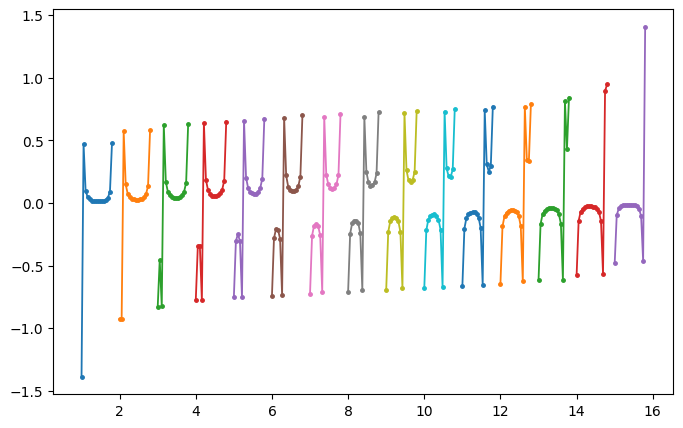

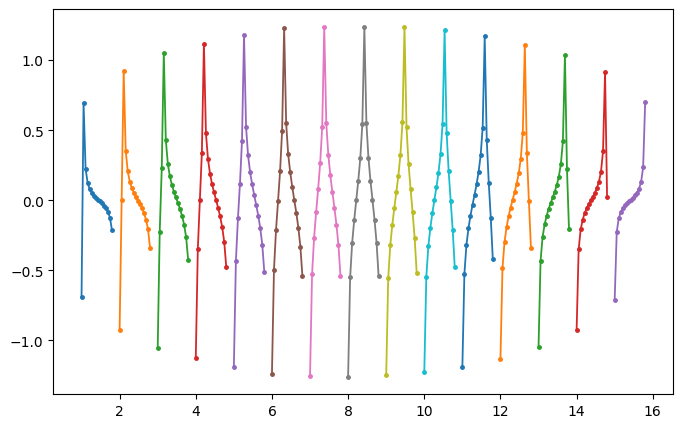

In [10]:
#Load data of background
mat = scipy.io.loadmat(DATAPATH+"datamat_1_0")
Uel=mat.get("Uel").T
CP=mat.get("CurrentPattern").T

#Selecting Potentials
Uel_b=Uel[-15:] #Matrix of measuarements
print(Uel_b.shape)

#Plot
fig, ax = plt.subplots(figsize=(8,5))
for i, U_vec in enumerate(Uel_b):
    x=np.linspace(1,1.8,16)+i
    ax.plot(x,U_vec, linewidth=1.3, marker='.', markersize=5);

#Selecting Potentials
list_U0_m=np.zeros_like(Uel_b)

#Converting data to our format
for index, potential in enumerate(Uel_b):
    list_U0_m[index]=eitx.ConvertingData(potential, method="KIT4")
list_U0=list_U0_m.flatten() #Matrix to vector

#Ploting converted data
fig, ax = plt.subplots(figsize=(8,5))
for i, U_vec in enumerate(list_U0_m):
    x=np.linspace(1,1.8,16)+i
    ax.plot(x,U_vec, linewidth=1.3, marker='.', markersize=5);


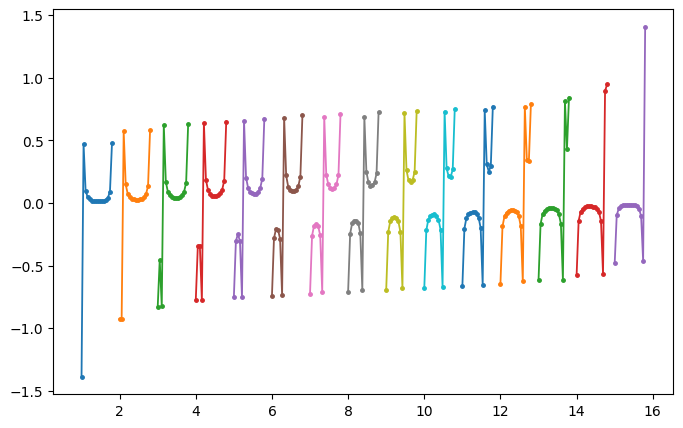

In [11]:
#Converting back to KIT4 format
converted_U0 = eitx.ConvertingData(list_U0_m,"adjacent")

# Plotting
fig, ax = plt.subplots(figsize=(8,5))
for i, U_vec in enumerate(converted_U0):
    x=np.linspace(1,1.8,16)+i
    ax.plot(x,U_vec, linewidth=1.3, marker='.', markersize=5)


In [12]:
#Checking difference
Uel_b - eitx.ConvertingData(list_U0_m,"adjacent")

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,

## Teste de geração de dados

- Gera algumas imagens de condutividade, com 1, 2 e 3 inclusões (2 amostras de cada);
- Plota cada imagem;
- Resolve o problema direto pra calcular os potenciais com a corrente $I$ fixada acima;
- Salva os dados de potenciais no nosso formato (aterrado), e no formato adjacente (do KIT4).

### Configurações

Error   : Gmsh has not been initialized


Info    : Meshing 1D...
Info    : Meshing curve 1 (Ellipse)
Info    : Done meshing 1D (Wall 0.0171639s, CPU 0.015342s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Delaunay)
Info    : Done meshing 2D (Wall 0.0778326s, CPU 0.077145s)
Info    : 2414 nodes 4027 elements


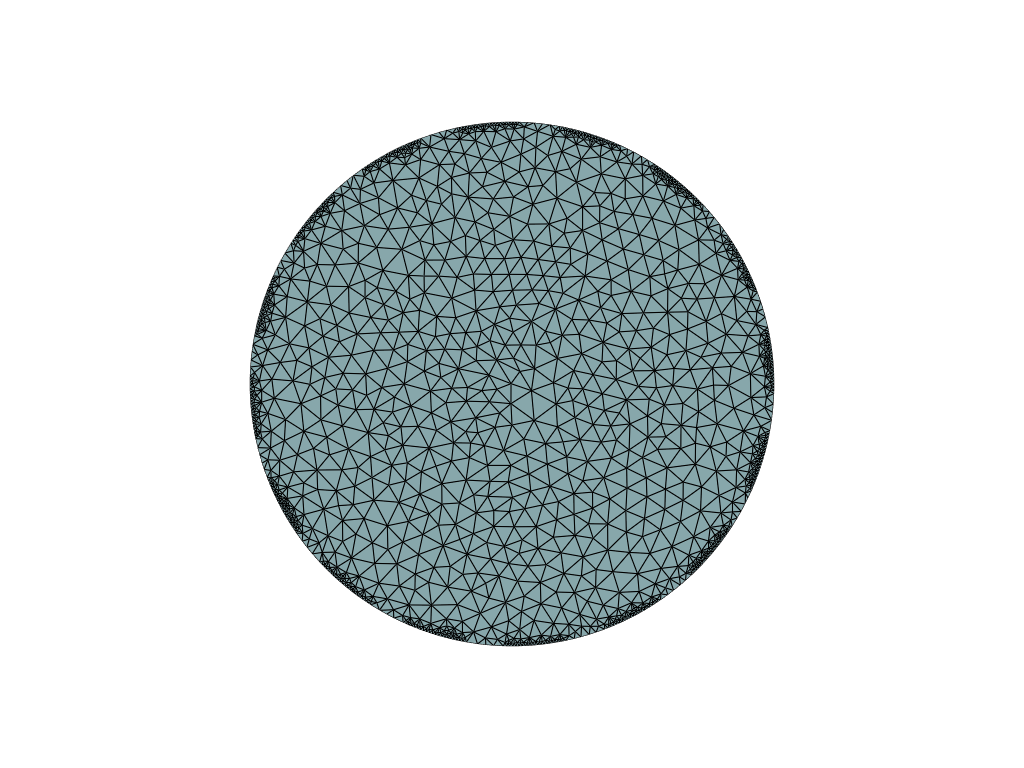

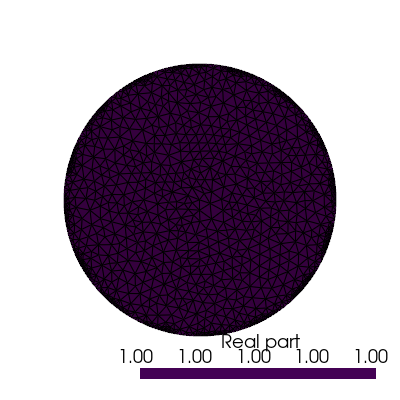

In [13]:
"Forward problem in background"
# Settings

#Loading data (somente para definir a corrente de maneira correta)
mat = sp.io.loadmat(DATAPATH+"datamat_1_2")
CP = mat.get("CurrentPattern").T

#Current
I_all=CP[-15:]/np.sqrt(2)
l, L=np.shape(I_all) #Number of experiments = 15, Number of Electrodes = 16
# print(I_all)# MESH (For real data)

"Basic Definitions"
radius=1               #Circle radius
per_cober=0.454728409  #Percentage of area covered by electrodes
rotate=0               #Electrodes Rotation
z=np.ones(L)*0.07858

'Return object with angular position of each electrode'
ele_pos = eitx.Electrodes(L, per_cober, rotate)
refine_n = 8     #Refinement mesh
n_in = 8         #Vertex on elec.
n_out = 2        #Vertex on gaps (Sometimes it is important.)

'Mesh'
# mesh_inverse=MyMesh(radius, refine_n, n_in, n_out, ele_pos)
mesh_object = eitx.MeshClass(ele_pos,0.4,0.4)
mesh = mesh_object.mesh


## Direct problem
dir_problem = eitx.DirectProblem(mesh_object,z)
V0 = dir_problem.V0   # Discontinuous Garlekin space function
V = dir_problem.V     # Continuous Garlekin space function

# 'Plot'
eitx.plot_mesh(mesh)

#"Define gamma as constant = Background"
iv, bg= 10, 1
gamma0 = dolfinx.fem.Function(V0)
gamma0.x.array[:] = bg

# "Plot"
eitx.plot_indicator_function(gamma0)

#Solving Forward Problem
list_u, list_U0_m = dir_problem.solve_problem_current(I_all, gamma0)
list_U0 = np.array(list_U0_m).flatten()

'Plot'
#np.set_printoptions(linewidth=750, precision=3, suppress=False, threshold=1000, formatter=None)
#print(np.matrix(np.round(list_U0_m, 3)))
'Retangular Mesh'

N = 128                               # grid with N*N points (works well with 0 < N < 400)
h = 2*radius/(N-1)                    # step size
x = [radius - i*h for i in range(N)]  # x grid points
y = [-radius + i*h for i in range(N)] # y grid points

# MESH x and y
mesh_x = np.zeros((N,N))              # x-Data (input of CNN)
mesh_y = np.zeros((N,N))              # y-Data (input of CNN)
for i in range(N):
  for j in range(N):
    mesh_x[i][j] = x[i]
    mesh_y[i][j] = y[j]

T1 = []                               # To save data

### Gerando os dados

Generating sample: 1


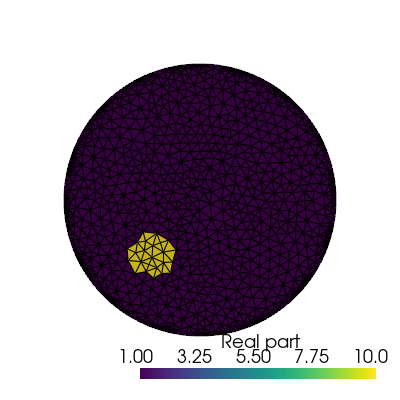

Generating sample: 2


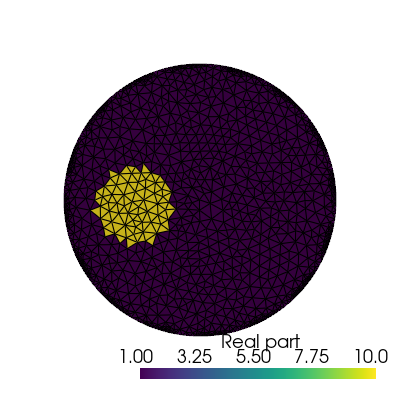

Generation of 1 circle(s) ended.
Generating sample: 3


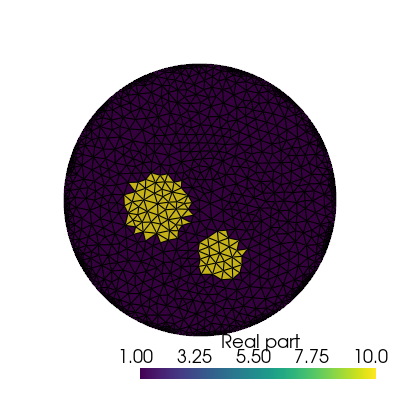

Generating sample: 4


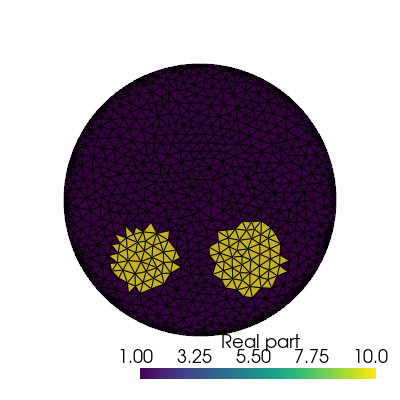

Generation of 2 circle(s) ended.
Generating sample: 5


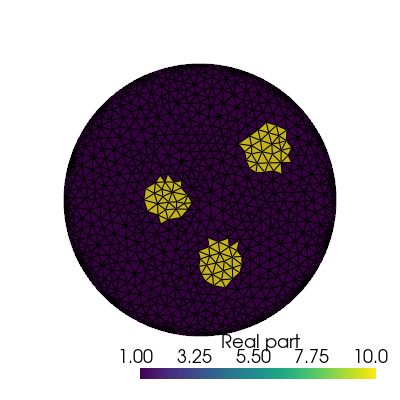

Generating sample: 6


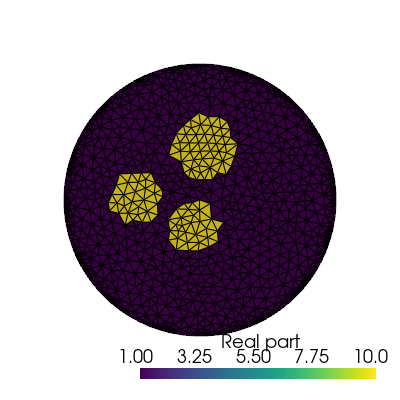

Generation of 3 circle(s) ended.


In [14]:
DBAR_PATH = "dbar_data/"

# Loop for generating data

n_samples = [2, 2, 2]               # number of samples in order: 1 circle, 2 circles, 3 circles, etc.
noise_level = 0.0                   # % of artificial noise in data

nn_samples = len(n_samples)
multi = 4                        # number of samples is multiplied by this number
for m in range(nn_samples):
  m_multi_m = (multi**m)*n_samples[m]
  rad_1 = np.random.uniform(0.15*radius, 0.3*radius, (m+1, m_multi_m))                # radius of the inclusions
  center_xy = np.random.uniform(-radius*0.5, radius*0.5, size=(2*(m+1), m_multi_m))   # xy-center of the inclusions
  # print(center_xy), print(rad_1), print(noise)
  vecpop = []                         # vector with indices to withdraw
  for p in range(m):
    for q in range(m - p):
      for j in range(m_multi_m):
        'withdraw indices when iclusions are overlapped'
        x0 = center_xy[2*p,j]
        y0 = center_xy[2*p+1,j]
        x1 = center_xy[2*(p+q)+2,j]
        y1 = center_xy[2*(p+q)+3,j]
        sumrad = rad_1[p,j] + rad_1[(p+q)+1,j]
        dist2 = (x0 - x1)**2 + (y0 - y1)**2
        if dist2 < sumrad**2 + 0.05*radius:               # if the circles touch each other
          vecpop.append(j)
  rad_1 = np.delete(rad_1,vecpop,1)     # remove the indices when the circles touch each other
  center_xy = np.delete(center_xy,vecpop,1)
  if rad_1.shape[1] < n_samples[m]:
    print('There are not enough samples. Correting the number of samples to: ' + str(rad_1.shape[1]))
    n_samples[m] = rad_1.shape[1]

  for sample in range(n_samples[m]):
    if m > 0:
      print('Generating sample: ' + str(np.sum(n_samples[:m]) + sample + 1))
    else:
      print('Generating sample: ' + str(sample + 1))

    "Generate Background + Inclusion"
    gamma = eitx.GammaCircle(V0,iv,bg,rad_1[0,sample],center_xy[0,sample], center_xy[1,sample])
    gamma_prov = gamma.x.array
    for p in range(m):
      ValuesCells1 = eitx.GammaCircle(V0,iv,0.0,rad_1[p+1,sample],center_xy[2*p+2,sample], center_xy[2*p+3,sample]).x.array
      gamma_prov = np.minimum(gamma_prov + ValuesCells1, iv)
    gamma.x.array[:]= gamma_prov

    #Plot and save fig
    eitx.plot_indicator_function(gamma,True,DBAR_PATH+f"fig/sample_{m}_{sample}")

    #Solve Forward Problem with Background + Inclusion
    list_u1, list_U1_m = dir_problem.solve_problem_current(I_all, gamma)

    np.save(DBAR_PATH+f"ground_format_potential/sample_{m}_{sample}",list_U1_m)
    np.save(DBAR_PATH+f"adjacent_format_potential/sample_{m}_{sample}",eitx.ConvertingData(list_U1_m,"adjacent"))
  
    "Define data in a homogeneus grid for training"
    T = np.zeros((l + 3,N,N))
    
    T[l] = mesh_x
    T[l+1] = mesh_y
    # T[l+2] = A
    T1.append(T)
  print('Generation of ' + str(m + 1) + ' circle(s) ended.')
# np.save('EIT_Data_for_CNN', T1)
# print('Data saved at file named: EIT_Data_for_CNN.')
# print(np.array(T1).shape)

In [1]:
import numpy as np
import scipy as sp

In [15]:
import os

adj_path = "dbar_data/adjacent_format_potential/"
grd_path = "dbar_data/ground_format_potential/"

adj_dir = os.listdir("dbar_data/adjacent_format_potential")
grd_dir = os.listdir("dbar_data/ground_format_potential")

Salvando arquivos .mat:

In [18]:
for file in adj_dir:
    sample = np.load(adj_path+file)
    print(sample)
    sp.io.savemat(adj_path+file+".mat",{"Uel":sample.T})

for file in grd_dir:
    sample = np.load(grd_path+file)
    print(sample)
    sp.io.savemat(grd_path+file+'.mat',{"Uel":sample.T})

[[-2.19553194  0.86519813  0.09976613  0.04409577  0.02746272  0.01899379
   0.01307966  0.008892    0.00722113  0.00853866  0.01113584  0.01334477
   0.02083839  0.04280986  0.09940326  0.91475185]
 [-1.33033382 -1.29243259  0.96792423  0.14356398  0.07292196  0.04623496
   0.0304872   0.01990685  0.01503835  0.01667823  0.02104416  0.02417971
   0.03515671  0.06808774  0.1442259   1.01731642]
 [-1.23056769 -0.42427449 -1.19100346  1.00958391  0.17522473  0.09154456
   0.05599316  0.03476183  0.02420539  0.02482529  0.03018483  0.03352076
   0.04611397  0.08546154  0.17133952  1.06308617]
 [-1.18647193 -0.32480627 -0.32498354 -1.18755831  1.09093877  0.19161846
   0.0989794   0.05706599  0.0361466   0.03356814  0.03894174  0.04190022
   0.05507989  0.09854197  0.19027778  1.09076111]
 [-1.15900921 -0.27934703 -0.22268077 -0.27184427 -1.1635774   1.1116815
   0.20015407  0.09839278  0.0550843   0.04458878  0.04823212  0.05003799
   0.06305717  0.10933579  0.2051261   1.11076806]
 [-1.1